In [ ]:
# Customer Churn Prediction
# Feature Engineering

# Import Required Libraries

This section imports all the libraries required for feature engineering, feature selection, and data preprocessing.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Clean Dataset

In [4]:
# Load the cleaned dataset

df = pd.read_csv("C:\\Users\\khale\\OneDrive\\Desktop\\project_depi\\customer-churn-prediction\\data\\cleaned\\customer_churn_cleaned.csv")

print("Dataset Loaded Successfully ✅")
print(df.shape)

Dataset Loaded Successfully ✅
(7032, 21)


# Dataset Overview

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

# Remove Unnecessary Features

In [12]:
# Drop customerID because it will not provide predictive information

df = df.drop(columns=["customerID"])

print("customerID column removed successfully ✅")
print(df.shape)

customerID column removed successfully ✅
(7032, 20)


In [13]:
# Display unique values for all categorical columns
# we did this step to understand the unique values in each categorical column, which will help us in encoding them later.
# also to specifiy columns to binary features.

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', '

C:\Users\khale\AppData\Local\Temp\ipykernel_24852\2368484950.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [14]:
for col in categorical_columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts())


gender
gender
Male      3549
Female    3483
Name: count, dtype: int64

Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

TechSupport
TechSupport
No             

# Binary Encoding

In [15]:
binary_mapping = {
    "gender": {"Female": 0, "Male": 1},
    "Partner": {"No": 0, "Yes": 1},
    "Dependents": {"No": 0, "Yes": 1},
    "PhoneService": {"No": 0, "Yes": 1},
    "PaperlessBilling": {"No": 0, "Yes": 1},
    "Churn": {"No": 0, "Yes": 1}
}

df.replace(binary_mapping, inplace=True)

print("Binary Encoding Completed ✅")

Binary Encoding Completed ✅


In [16]:
# To ensure it has been encoded correctly.
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


# One-Hot Encoding

In [17]:
multi_class_columns = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df = pd.get_dummies(
    df,
    columns=multi_class_columns,
    drop_first=True,
    dtype=int
)

print("One-Hot Encoding Completed ✅")
print(df.shape)

One-Hot Encoding Completed ✅
(7032, 31)


# Feature Selection

In [18]:
# Split features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7032, 30)
Target Shape: (7032,)


In [20]:
# Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y.astype(int))

print("Random Forest Trained Successfully ✅")

Random Forest Trained Successfully ✅


In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,TotalCharges,0.196956
4,tenure,0.174033
7,MonthlyCharges,0.170995
28,PaymentMethod_Electronic check,0.037164
11,InternetService_Fiber optic,0.037130
26,Contract_Two year,0.030005
0,gender,0.027656
6,PaperlessBilling,0.025741
14,OnlineSecurity_Yes,0.025680
20,TechSupport_Yes,0.023105


## Feature Importance Visualization

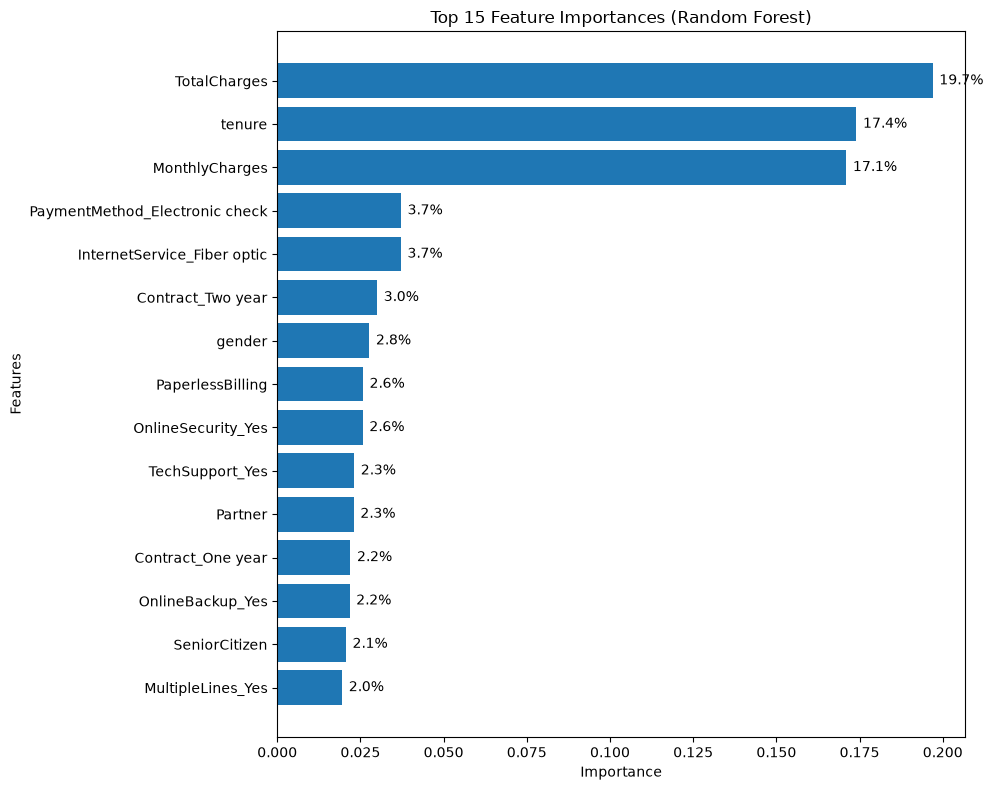

In [23]:
import matplotlib.pyplot as plt

# Top 15 Features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances (Random Forest)")

# Display importance values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width*100:.1f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Calculate Mutual Information Scores
mi_scores = mutual_info_classif(
    X,
    y.astype(int),
    random_state=42
)

mi_scores = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

mi_scores = mi_scores.sort_values(
    by="MI Score",
    ascending=False
)

mi_scores.head(15)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.